# Airline NLP Analytics

This notebook uses Tweets.csv and AirlineReviews.csv to perform:
- Sentiment analysis (positive / negative / neutral)
- Aspect-based sentiment analysis: food, delays, staff, seat comfort, baggage, check-in, wi-fi
- Complaint classification
- Emotion detection: frustration, anger, satisfaction, stress
- Feedback history analysis
- Churn signal detection
- Dissatisfied frequent flyers (proxy from tweet user names)
- Loyalty drivers
- Smart recommendation system

## Data sources
- data/Tweets.csv (text + airline_sentiment)
- data/AirlineReviews.csv (Title, Review, OverallScore, Recommended)

Notes:
- Review sentiment labels are derived from OverallScore: <=4 negative, 5-6 neutral, >=7 positive.
- If OverallScore is missing, Recommended=yes/no is used.
- Some tasks use heuristics and keyword rules for transparency.

In [18]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.preprocessing import label_binarize

plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid", palette="muted")

In [19]:
base_dir = Path.cwd()
if not (base_dir / "data").exists():
    for parent in base_dir.parents:
        if (parent / "data").exists():
            base_dir = parent
            break

data_dir = base_dir / "data"
if not data_dir.exists():
    raise FileNotFoundError(f"data folder not found from {Path.cwd()}")

reviews_path = data_dir / "AirlineReviews.csv"
tweets_path = data_dir / "Tweets.csv"

if not reviews_path.exists():
    raise FileNotFoundError(f"Missing file: {reviews_path}")
if not tweets_path.exists():
    raise FileNotFoundError(f"Missing file: {tweets_path}")

df_reviews = pd.read_csv(
    reviews_path,
    usecols=lambda c: c in {
        "Title", "Review", "OverallScore", "Recommended",
        "DatePub", "DateFlown", "AirlineName", "OriginCountry",
        "TravelType", "TripVerified", "CabinType", "Route",
        "unique_id"
    },
    low_memory=False
)
df_tweets = pd.read_csv(
    tweets_path,
    usecols=lambda c: c in {
        "text", "airline_sentiment", "tweet_created",
        "airline", "name", "tweet_location", "user_timezone"
    },
    low_memory=False
)

print(f"Reviews rows: {len(df_reviews):,}")
print(f"Tweets rows : {len(df_tweets):,}")

Reviews rows: 129,455
Tweets rows : 14,640


In [20]:
def build_review_labels(df):
    text_cols = [c for c in ["Title", "Review"] if c in df.columns]
    if text_cols:
        df["text"] = df[text_cols].fillna("").astype(str).agg(" ".join, axis=1).str.strip()
    else:
        df["text"] = ""

    score = pd.to_numeric(df.get("OverallScore"), errors="coerce")
    df["label"] = pd.cut(score, bins=[-1, 4, 6, 10], labels=["negative", "neutral", "positive"])

    rec = df.get("Recommended")
    if rec is not None:
        rec = rec.astype(str).str.lower()
        df.loc[df["label"].isna(), "label"] = rec.map({"yes": "positive", "no": "negative"})

    df["date"] = pd.to_datetime(df.get("DatePub"), errors="coerce")
    df["source"] = "reviews"
    df["airline"] = df.get("AirlineName")
    df["user_id"] = df.get("unique_id")
    df["travel_type"] = df.get("TravelType")
    return df[["source", "text", "label", "date", "airline", "user_id", "travel_type"]]

df_reviews = build_review_labels(df_reviews)

df_tweets = df_tweets.rename(columns={"airline_sentiment": "label"})
df_tweets["label"] = df_tweets["label"].astype(str).str.lower()
df_tweets = df_tweets[df_tweets["label"].isin(["negative", "neutral", "positive"])]
df_tweets["text"] = df_tweets["text"].astype(str)
df_tweets["date"] = pd.to_datetime(df_tweets.get("tweet_created"), errors="coerce")
df_tweets["source"] = "tweets"
df_tweets["airline"] = df_tweets.get("airline")
df_tweets["user_id"] = df_tweets.get("name")
df_tweets["travel_type"] = None
df_tweets = df_tweets[["source", "text", "label", "date", "airline", "user_id", "travel_type"]]

df_all = pd.concat([df_reviews, df_tweets], ignore_index=True)
df_all["text"] = df_all["text"].fillna("").str.strip()
df_all = df_all[df_all["text"].str.len() > 0].reset_index(drop=True)

print("Label distribution:")
print(df_all["label"].value_counts())

Label distribution:
label
negative    82322
positive    48866
neutral     12907
Name: count, dtype: int64


## 1. Sentiment analysis

In [21]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub("http\\S+|www\\S+", " ", text)
    text = re.sub("@\\w+", " ", text)
    text = re.sub("#\\w+", " ", text)
    text = re.sub("[^a-z0-9\\s]", " ", text)
    text = re.sub("\\s+", " ", text).strip()
    return text

df_all["text_clean"] = df_all["text"].map(clean_text)

X = df_all["text_clean"]
y = df_all["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=15000, stop_words="english")
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

clf = LogisticRegression(max_iter=2000, class_weight="balanced", multi_class="ovr")
clf.fit(X_train_vec, y_train)

y_pred = clf.predict(X_test_vec)
proba = clf.predict_proba(X_test_vec)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")
y_bin = label_binarize(y_test, classes=clf.classes_)
auc = roc_auc_score(y_bin, proba, average="macro")

print(f"Accuracy={acc:.3f}  F1(w)={f1:.3f}  ROC-AUC={auc:.3f}")
print(classification_report(y_test, y_pred))

X_all_vec = tfidf.transform(X)
df_all["pred_sentiment"] = clf.predict(X_all_vec)
df_all["pred_confidence"] = clf.predict_proba(X_all_vec).max(axis=1)

# === Enhanced sentiment analysis: keyword-based overrides + clause-level support ===

POSITIVE_KEYWORDS = [
    "loyal customer", "loyalty", "love", "loved", "great", "excellent",
    "amazing", "friendly", "wonderful", "fantastic", "awesome", "delighted",
    "outstanding", "superb", "perfect", "best experience", "recommend",
    "thank you", "appreciate", "pleased",
]
NEGATIVE_KEYWORDS = [
    "disappointing", "disappointed", "terrible", "horrible", "awful",
    "worst", "ruined", "unhelpful", "rude", "frustrating", "annoying",
    "useless", "waste of money", "nightmare", "appalling", "ridiculous",
]

def _has_phrase(cleaned, phrase):
    if " " in phrase:
        return phrase in cleaned
    return re.search(r"\b" + re.escape(phrase) + r"\b", cleaned) is not None

def _has_any(cleaned, phrases):
    return any(_has_phrase(cleaned, p) for p in phrases)

def _make_pattern(words):
    words = [re.escape(w) for w in words]
    return r"(?:\b" + "|".join(words) + r"\b)"

# Split text into clauses on punctuation + contrast connectors
_CONTRAST_SPLIT = re.compile(
    r"(?:[\.;!\?\n]+)|(?:,?\s*\b(?:but|however|although|though|yet|whereas|while|despite|even though|on the other hand)\b\s*)",
    flags=re.IGNORECASE,
)

def split_clauses(raw_text):
    parts = _CONTRAST_SPLIT.split(str(raw_text))
    return [p.strip() for p in parts if p and p.strip()]

def detect_churn_in(cleaned):
    if "churn_terms" not in globals():
        return False
    pat = "|".join(re.escape(t) for t in churn_terms)
    return bool(re.search(pat, cleaned))

def predict_sentiment(raw_clause):
    """Returns (sentiment, confidence, cleaned_text, is_churn).
    Applies rule-based overrides (loyalty/churn keywords) on top of TF-IDF model
    so short clauses are classified correctly even with weak signal."""
    cleaned = clean_text(raw_clause)
    if not cleaned:
        return "neutral", 0.0, cleaned, False

    vec = tfidf.transform([cleaned])
    pred = clf.predict(vec)[0]
    conf = float(np.max(clf.predict_proba(vec)[0]))

    is_churn = detect_churn_in(cleaned)
    has_neg_kw = _has_any(cleaned, NEGATIVE_KEYWORDS)
    has_pos_kw = _has_any(cleaned, POSITIVE_KEYWORDS)

    # Priority: churn / negative keywords > positive keywords > model
    if is_churn or has_neg_kw:
        if pred != "negative":
            pred = "negative"
            conf = 0.95 if is_churn else 0.90
    elif has_pos_kw:
        if pred != "positive":
            pred = "positive"
            conf = 0.90

    return pred, conf, cleaned, is_churn

def detect_aspects_in(cleaned):
    """Returns list of aspect names found in the cleaned text."""
    if "aspects" not in globals():
        return []
    found = []
    for name, keywords in aspects.items():
        pattern = _make_pattern(keywords)
        if re.search(pattern, cleaned):
            found.append(name)
    return found

def detect_emotion_in(cleaned):
    """Returns the primary emotion detected in the cleaned text."""
    if "emotion_lex" not in globals():
        return "neutral"
    scores = {}
    for emo, keys in emotion_lex.items():
        scores[emo] = sum(1 for k in keys if k in cleaned)
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else "neutral"

def classify_complaint_in(cleaned):
    """Returns complaint category based on keywords in the cleaned text."""
    if "complaint_rules" not in globals():
        return "other"
    for cat, keys in complaint_rules.items():
        for k in keys:
            if k in cleaned:
                return cat
    return "other"

c:\Users\RaedCHARRAD\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy=0.835  F1(w)=0.845  ROC-AUC=0.911
              precision    recall  f1-score   support

    negative       0.93      0.87      0.90     16464
     neutral       0.33      0.46      0.38      2582
    positive       0.88      0.88      0.88      9773

    accuracy                           0.84     28819
   macro avg       0.71      0.74      0.72     28819
weighted avg       0.86      0.84      0.84     28819



## 2. Aspect-based sentiment analysis

In [22]:
aspects = {
    "food": ["food", "meal", "snack", "drink", "beverage", "catering"],
    "delays": ["delay", "delayed", "late", "cancel", "cancelled", "canceled", "reschedule", "missed", "waiting", "hold"],
    "staff": ["staff", "crew", "attendant", "service", "agent", "desk", "support", "help"],
    "seat_comfort": ["seat", "legroom", "leg room", "recline", "comfort", "cabin", "space"],
    "baggage": ["baggage", "bag", "luggage", "lost", "claim", "carry-on", "carryon"],
    "check_in": ["check-in", "check in", "boarding", "gate", "security", "tsa", "counter"],
    "wifi": ["wifi", "wi-fi", "internet", "connection", "online"]
}

def make_pattern(words):
    words = [re.escape(w) for w in words]
    return "(?:\\b" + "|".join(words) + "\\b)"

for name, words in aspects.items():
    pattern = make_pattern(words)
    df_all[f"aspect_{name}"] = df_all["text_clean"].str.contains(pattern, regex=True, na=False)

aspect_rows = []
for name in aspects:
    mask = df_all[f"aspect_{name}"]
    if mask.any():
        dist = df_all.loc[mask, "pred_sentiment"].value_counts(normalize=True) * 100
        aspect_rows.append({
            "aspect": name,
            "count": int(mask.sum()),
            "pos_pct": round(dist.get("positive", 0), 1),
            "neu_pct": round(dist.get("neutral", 0), 1),
            "neg_pct": round(dist.get("negative", 0), 1)
        })

aspect_df = pd.DataFrame(aspect_rows).sort_values("count", ascending=False)
aspect_df

,aspect,count,pos_pct,neu_pct,neg_pct
2,staff,103102,40.8,10.8,48.4
3,seat_comfort,71734,47.8,14.4,37.7
1,delays,64138,20.2,7.6,72.3
0,food,58662,53.7,15.8,30.5
5,check_in,48666,34.7,10.2,55.1
4,baggage,38771,26.0,7.9,66.1
6,wifi,18004,30.7,9.8,59.4


## 3. Complaint classification

In [23]:
complaint_rules = {
    "delays_cancellations": ["delay", "delayed", "late", "cancel", "cancelled", "canceled", "missed", "reschedule"],
    "baggage_issues": ["baggage", "bag", "luggage", "lost", "claim", "damaged"],
    "staff_service": ["rude", "staff", "crew", "attendant", "agent", "support", "service", "help"],
    "seat_comfort": ["seat", "legroom", "recline", "comfort", "space"],
    "check_in_boarding": ["check-in", "check in", "boarding", "gate", "counter", "security", "tsa"],
    "food_quality": ["food", "meal", "snack", "drink", "beverage"],
    "wifi_entertainment": ["wifi", "wi-fi", "internet", "entertainment", "tv"],
    "booking_refund": ["booking", "booked", "reservation", "refund", "charge", "fee", "price", "pricing"]
}

def classify_complaint(text):
    for cat, keys in complaint_rules.items():
        for k in keys:
            if k in text:
                return cat
    return "other"

df_all["complaint_category"] = "none"
neg_mask = df_all["pred_sentiment"] == "negative"
df_all.loc[neg_mask, "complaint_category"] = df_all.loc[neg_mask, "text_clean"].apply(classify_complaint)

df_all["complaint_category"].value_counts()

complaint_category
none                    67351
delays_cancellations    42901
staff_service           13713
baggage_issues          11358
other                    3806
seat_comfort             2504
booking_refund           1064
check_in_boarding         900
food_quality              351
wifi_entertainment        147
Name: count, dtype: int64

## 4. Emotion detection

In [24]:
emotion_lex = {
    "frustration": ["frustrat", "annoy", "upset", "fed up", "tired of", "irritat"],
    "anger": ["angry", "furious", "mad", "rage", "pissed", "outrage"],
    "satisfaction": ["happy", "pleased", "great", "amazing", "love", "excellent", "awesome", "delight"],
    "stress": ["stress", "anxious", "worried", "panic", "nervous", "pressure"]
}

def detect_emotion(text):
    scores = {}
    for emo, keys in emotion_lex.items():
        scores[emo] = sum(1 for k in keys if k in text)
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else "neutral"

df_all["emotion"] = df_all["text_clean"].apply(detect_emotion)
df_all["emotion"].value_counts()

emotion
neutral         86605
satisfaction    25434
anger           23794
frustration      6005
stress           2257
Name: count, dtype: int64

## 5. Feedback history

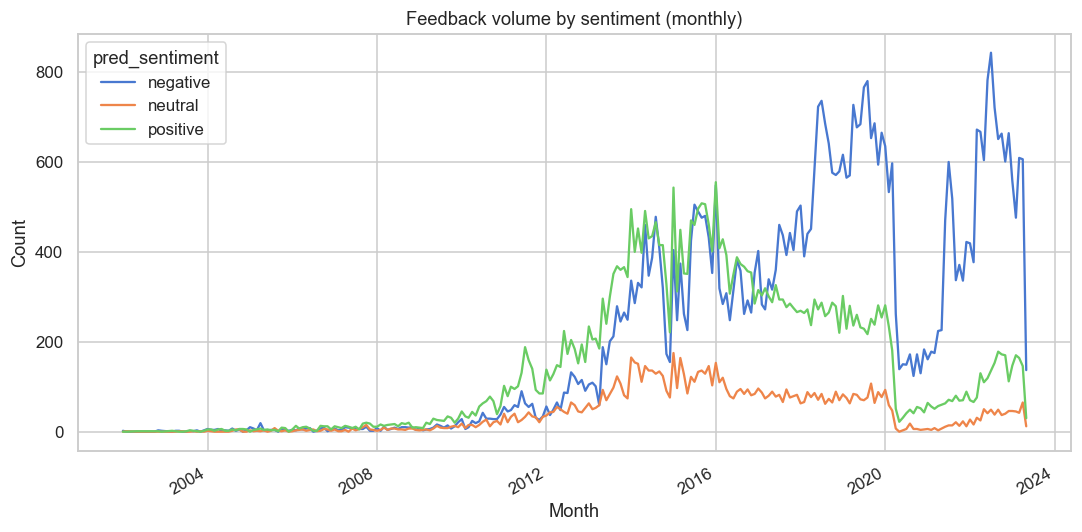

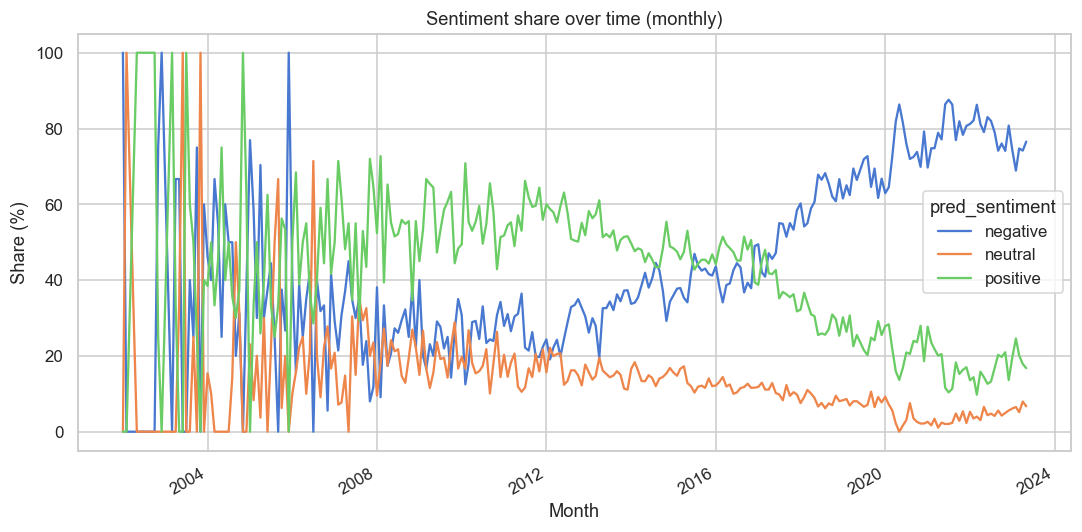

In [25]:
df_hist = df_all.copy()
df_hist["date"] = pd.to_datetime(df_hist["date"], errors="coerce")
df_hist = df_hist.dropna(subset=["date"]).copy()
if df_hist.empty:
    print("No valid dates found for history analysis.")
else:
    df_hist["month"] = df_hist["date"].dt.to_period("M").dt.to_timestamp()
    trend = df_hist.groupby(["month", "pred_sentiment"]).size().unstack(fill_value=0)
    trend.plot(kind="line")
    plt.title("Feedback volume by sentiment (monthly)")
    plt.xlabel("Month")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    trend_pct = trend.div(trend.sum(axis=1), axis=0) * 100
    trend_pct.plot(kind="line")
    plt.title("Sentiment share over time (monthly)")
    plt.xlabel("Month")
    plt.ylabel("Share (%)")
    plt.tight_layout()
    plt.show()

## 6. Churn signal detection

In [26]:
churn_terms = [
    "never fly", "never again", "wont fly", "won't fly", "stop flying",
    "switch", "boycott", "cancel membership", "close account",
    "refund", "chargeback", "take my business", "lost my business"
]
pattern = "|".join([re.escape(t) for t in churn_terms])
df_all["churn_signal"] = df_all["text_clean"].str.contains(pattern, regex=True, na=False)

print(df_all["churn_signal"].value_counts())
df_all.loc[df_all["churn_signal"], ["source", "airline", "pred_sentiment", "text"]].head(5)

churn_signal
False    126010
True      18085
Name: count, dtype: int64


,source,airline,pred_sentiment,text
10,reviews,Adria Airways,negative,I will never fly again with Adria Please do a ...
13,reviews,Adria Airways,negative,worse than the budget airlines Ljubljana to Zü...
24,reviews,Adria Airways,negative,should be ashamed of their operations Ljubljan...
27,reviews,Adria Airways,negative,never fly this airline again Ljubljana to Muni...
33,reviews,Adria Airways,negative,"fleet is tired and outdated ✅ , | Munich to L..."


## 7. Dissatisfied frequent flyers (tweets proxy)

In [27]:
df_t = df_all[(df_all["source"] == "tweets") & df_all["user_id"].notna()].copy()
if df_t.empty:
    print("No tweet user ids available.")
else:
    freq = df_t.groupby("user_id").agg(
        total=("user_id", "size"),
        neg_rate=("pred_sentiment", lambda s: (s == "negative").mean())
    )
    freq = freq[freq["total"] >= 3].sort_values(["neg_rate", "total"], ascending=False)
    freq.head(10)

## 8. Loyalty drivers

In [28]:
if "positive" in clf.classes_:
    pos_idx = list(clf.classes_).index("positive")
    coef = clf.coef_[pos_idx]
    top_pos = pd.Series(coef, index=tfidf.get_feature_names_out()).nlargest(20)
    top_pos
else:
    print("Positive class not found in model classes.")

aspect_pos = []
for name in aspects:
    mask = df_all[f"aspect_{name}"]
    if mask.any():
        pos_rate = (df_all.loc[mask, "pred_sentiment"] == "positive").mean() * 100
        aspect_pos.append({
            "aspect": name,
            "positive_rate_pct": round(pos_rate, 1),
            "count": int(mask.sum())
        })
pd.DataFrame(aspect_pos).sort_values("positive_rate_pct", ascending=False)

,aspect,positive_rate_pct,count
0,food,53.7,58662
3,seat_comfort,47.8,71734
2,staff,40.8,103102
5,check_in,34.7,48666
6,wifi,30.7,18004
4,baggage,26.0,38771
1,delays,20.2,64138


## 9. Smart recommendation system

In [29]:
def recommend_actions(row):
    actions = []
    if row["pred_sentiment"] == "negative":
        if row.get("aspect_delays"):
            actions.append("Offer delay compensation and proactive rebooking")
        if row.get("aspect_baggage"):
            actions.append("Provide baggage tracking and priority handling")
        if row.get("aspect_staff"):
            actions.append("Service recovery follow-up and staff coaching")
        if row.get("aspect_check_in"):
            actions.append("Streamline check-in and boarding support")
        if row.get("aspect_wifi"):
            actions.append("Wi-Fi credit or connectivity fix")
        if row.get("aspect_food"):
            actions.append("Meal or voucher compensation")
        if row.get("aspect_seat_comfort"):
            actions.append("Seat comfort fix or seat upgrade credit")
    else:
        actions.append("Invite to loyalty program or add bonus points")
        if row.get("aspect_seat_comfort"):
            actions.append("Suggest premium seat upgrade")
        if row.get("aspect_wifi"):
            actions.append("Offer premium Wi-Fi package")

    if row.get("churn_signal"):
        actions.append("Priority retention outreach")

    travel = str(row.get("travel_type") or "").lower()
    if "business" in travel:
        actions.append("Offer lounge access and flexible ticket options")

    if not actions:
        actions.append("General service follow-up")
    return actions

sample = df_all.sample(5, random_state=42).copy()
sample["recommendations"] = sample.apply(recommend_actions, axis=1)
sample["text_short"] = sample["text"].str.slice(0, 120)
sample[["source", "airline", "pred_sentiment", "emotion", "complaint_category", "churn_signal", "text_short", "recommendations"]]

,source,airline,pred_sentiment,emotion,complaint_category,churn_signal,text_short,recommendations
111717,reviews,TAP Portugal,neutral,neutral,none,False,"the plane was very clean ✅ , | Flying TP929 f...",[Invite to loyalty program or add bonus points...
17980,reviews,AirAsia,negative,anger,delays_cancellations,False,"had about 30 minutes to run ✅ , | Flew AirAsi...",[Offer delay compensation and proactive rebook...
120634,reviews,United Airlines,negative,anger,delays_cancellations,False,recent experience was absolutely horrible I fl...,[Offer delay compensation and proactive rebook...
117049,reviews,VietJet Air,negative,frustration,delays_cancellations,False,VietJet is always delayed Taipei to Ho Chi Min...,[Offer delay compensation and proactive rebook...
17818,reviews,Alaska Airlines,negative,neutral,staff_service,False,we still haven't left the gate Seattle to Tamp...,[Service recovery follow-up and staff coaching...


In [37]:
# --- Test one text input (with mixed-sentiment / aspect-level breakdown) ---
from IPython.display import HTML, display
import html as _html

# === Configuration ===
test_text = "Food quality was excellent"
test_user_id = None
test_airline = None
test_date = None
test_travel_type = None

if not test_text or not str(test_text).strip():
    raise ValueError("test_text is empty. Paste a message and rerun.")
if "clf" not in globals() or "tfidf" not in globals():
    raise ValueError("Run the sentiment analysis cell before testing.")
if "aspects" not in globals():
    raise ValueError("Aspects not found. Run the aspect-based cell first.")

# === Analysis (uses pre-defined functions from training cells) ===

overall_pred, overall_conf, full_clean, full_churn = predict_sentiment(test_text)
overall_aspects = detect_aspects_in(full_clean)
overall_emotion = detect_emotion_in(full_clean)
overall_complaint = classify_complaint_in(full_clean) if overall_pred == "negative" else "none"

clauses = split_clauses(test_text)
clause_rows = []
aspect_sentiment = {}

for cl in clauses:
    sent, conf, cleaned, is_churn = predict_sentiment(cl)
    asp = detect_aspects_in(cleaned)
    clause_rows.append({
        "clause": cl,
        "sentiment": sent,
        "confidence": conf,
        "aspects": asp,
        "churn": is_churn,
    })
    for a in asp:
        aspect_sentiment.setdefault(a, {"positive": [], "negative": [], "neutral": []})
        aspect_sentiment[a][sent].append(cl)

churn_signal = full_churn or any(r["churn"] for r in clause_rows)
clause_sents = {r["sentiment"] for r in clause_rows}
is_mixed = ("positive" in clause_sents) and ("negative" in clause_sents)
overall_verdict = "mixed" if is_mixed else overall_pred

aspect_verdict = {}
for a, buckets in aspect_sentiment.items():
    has_pos, has_neg = bool(buckets["positive"]), bool(buckets["negative"])
    if has_pos and has_neg:
        aspect_verdict[a] = "mixed"
    elif has_pos:
        aspect_verdict[a] = "positive"
    elif has_neg:
        aspect_verdict[a] = "negative"
    else:
        aspect_verdict[a] = "neutral"

row = {"pred_sentiment": overall_pred, "churn_signal": churn_signal, "travel_type": test_travel_type}
for name in aspects:
    row[f"aspect_{name}"] = aspect_verdict.get(name) in ("negative", "mixed")

effective_sentiment_for_reco = "negative" if any(v in ("negative", "mixed") for v in aspect_verdict.values()) else overall_pred
row["pred_sentiment"] = effective_sentiment_for_reco
recommendations = recommend_actions(row) if "recommend_actions" in globals() else []

# === Display ===

ASPECT_LABELS = {
    "food": "Food & beverage", "delays": "Delays / cancellations", "staff": "Staff & crew",
    "seat_comfort": "Seat comfort", "baggage": "Baggage", "check_in": "Check-in / boarding", "wifi": "Wi-Fi",
}
SENT_COLORS = {
    "positive": ("#16a34a", "#dcfce7", "[+]"),
    "negative": ("#dc2626", "#fee2e2", "[-]"),
    "neutral":  ("#6b7280", "#f3f4f6", "[ ]"),
    "mixed":    ("#d97706", "#fef3c7", "[~]"),
}

def _pill(text, color, bg):
    return f'<span style="background:{bg};color:{color};padding:2px 10px;border-radius:999px;font-size:12px;font-weight:600;border:1px solid {color}22;">{_html.escape(text)}</span>'

def _aspect_card(aspect_key, verdict, quotes_by_sent):
    color, bg, icon = SENT_COLORS[verdict]
    label = ASPECT_LABELS.get(aspect_key, aspect_key)
    quote_html = "".join(
        f'<div style="margin-top:6px;padding:6px 10px;background:{_bg};border-left:3px solid {_c};border-radius:4px;font-size:13px;color:#111;"><span style="color:{_c};font-weight:700;margin-right:6px;">{_i}</span><i>"{_html.escape(q)}"</i></div>'
        for s in ("positive", "negative", "neutral") for q in quotes_by_sent.get(s, [])
        for (_c, _bg, _i) in [SENT_COLORS[s]]
    )
    return f'<div style="border:1px solid #e5e7eb;border-radius:10px;padding:12px 14px;margin:8px 0;background:#fff;"><div style="display:flex;align-items:center;justify-content:space-between;"><div style="font-weight:700;font-size:14px;color:#111;">{icon} {_html.escape(label)}</div>{_pill(verdict.upper(), color, bg)}</div>{quote_html}</div>'

sent_color, sent_bg = SENT_COLORS[overall_verdict][:2]
mixed_banner = f'<div style="margin-top:10px;padding:10px 14px;background:{SENT_COLORS["mixed"][1]};border-left:4px solid {SENT_COLORS["mixed"][0]};border-radius:6px;color:#111;font-size:13px;"><b>[~] Mixed sentiment detected.</b> Different parts express opposite feelings - see the per-aspect breakdown below.</div>' if is_mixed else ""

aspect_cards_html = "".join(_aspect_card(a, aspect_verdict[a], aspect_sentiment[a]) for a in aspect_sentiment) or '<div style="padding:10px;color:#6b7280;font-size:13px;">No specific aspect mentioned.</div>'

def _clause_row(r):
    churn_badge = '<span style="background:#fee2e2;color:#dc2626;padding:1px 8px;border-radius:999px;font-size:11px;font-weight:700;margin-left:6px;border:1px solid #dc262633;">CHURN</span>' if r["churn"] else ''
    aspects_str = ", ".join(ASPECT_LABELS.get(a, a) for a in r["aspects"]) or "-"
    return f'<tr><td style="padding:6px 10px;border-bottom:1px solid #f1f5f9;font-size:13px;"><i>"{_html.escape(r["clause"])}"</i> {churn_badge}</td><td style="padding:6px 10px;border-bottom:1px solid #f1f5f9;white-space:nowrap;">{_pill(r["sentiment"], *SENT_COLORS[r["sentiment"]][:2])}<span style="color:#6b7280;font-size:12px;margin-left:6px;">{r["confidence"]*100:.0f}%</span></td><td style="padding:6px 10px;border-bottom:1px solid #f1f5f9;font-size:12px;color:#374151;">{aspects_str}</td></tr>'

clause_table = "".join(_clause_row(r) for r in clause_rows)

reco_html = "".join(f'<li style="margin:4px 0;font-size:13px;color:#111;">{_html.escape(a)}</li>' for a in recommendations) or '<li style="color:#6b7280;font-size:13px;">No specific action needed.</li>'

meta_pills = " ".join([
    _pill(f"emotion: {overall_emotion}", "#7c3aed", "#ede9fe"),
    _pill(f"complaint: {overall_complaint}", "#0891b2", "#cffafe"),
    _pill("CHURN RISK" if churn_signal else "no churn signal", "#dc2626" if churn_signal else "#6b7280", "#fee2e2" if churn_signal else "#f3f4f6"),
])

html_out = f"""<div style="font-family:Segoe UI,Roboto,system-ui,Arial,sans-serif;max-width:880px;border:1px solid #e5e7eb;border-radius:14px;padding:20px;background:#fafafa;"><div style="font-size:12px;color:#6b7280;letter-spacing:.08em;text-transform:uppercase;">NLP analysis</div><div style="margin-top:6px;font-size:16px;color:#111;line-height:1.45;"><b>Input:</b> <i>"{_html.escape(test_text)}"</i></div><div style="margin-top:14px;display:flex;align-items:center;gap:10px;flex-wrap:wrap;"><div style="font-size:13px;color:#374151;">Overall sentiment</div>{_pill(overall_verdict.upper(), sent_color, sent_bg)}<span style="color:#6b7280;font-size:12px;">model confidence {overall_conf*100:.0f}%</span></div>{mixed_banner}<div style="margin-top:18px;font-weight:700;color:#111;">Aspect breakdown</div>{aspect_cards_html}<div style="margin-top:18px;font-weight:700;color:#111;">Clause-by-clause</div><table style="width:100%;border-collapse:collapse;background:#fff;border:1px solid #e5e7eb;border-radius:8px;overflow:hidden;margin-top:6px;"><thead><tr style="background:#f9fafb;text-align:left;"><th style="padding:8px 10px;font-size:12px;color:#374151;">Clause</th><th style="padding:8px 10px;font-size:12px;color:#374151;">Sentiment</th><th style="padding:8px 10px;font-size:12px;color:#374151;">Aspects</th></tr></thead><tbody>{clause_table}</tbody></table><div style="margin-top:18px;display:flex;gap:8px;flex-wrap:wrap;">{meta_pills}</div><div style="margin-top:18px;font-weight:700;color:#111;">Recommended actions</div><ul style="margin:6px 0 0 18px;padding:0;">{reco_html}</ul></div>"""

display(HTML(html_out))

result = {
    "input": test_text,
    "overall_sentiment": overall_verdict,
    "model_sentiment": overall_pred,
    "confidence": round(overall_conf, 3),
    "is_mixed": is_mixed,
    "aspect_verdict": aspect_verdict,
    "clauses": clause_rows,
    "emotion": overall_emotion,
    "complaint_category": overall_complaint,
    "churn_signal": churn_signal,
    "recommendations": recommendations,
}
result


Clause,Sentiment,Aspects
"""Food quality was excellent""",positive78%,Food & beverage


{'input': 'Food quality was excellent',
 'overall_sentiment': 'positive',
 'model_sentiment': 'positive',
 'confidence': 0.779,
 'is_mixed': False,
 'aspect_verdict': {'food': 'positive'},
 'clauses': [{'clause': 'Food quality was excellent',
   'sentiment': 'positive',
   'confidence': 0.7793146413748733,
   'aspects': ['food'],
   'churn': False}],
 'emotion': 'satisfaction',
 'complaint_category': 'none',
 'churn_signal': False,
 'recommendations': ['Invite to loyalty program or add bonus points']}